# Using Logistic Regression to Predict Risk Factors of CVD

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

# pip install sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


log_bang = pd.read_csv(
    "/Users/lilahduboff/Documents/Duke_Machine_Learning/Final/IDS705_ML_Final_Project_Cardiovasular_Disease/00_Cleaned_Data/bangladesh_logistic.csv"
)

log_bang.head()

,Sex,Age,BMI,Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,CVD Risk Level,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score
0,1,32.0000,23.6,125/79,248.0,78.0,111.0,0,1,0,0,1,125.0,79.0,1,140.0,17.93
1,1,55.0000,41.6,139/70,162.0,50.0,135.0,1,1,2,1,1,139.0,70.0,2,82.0,20.51
2,0,47.0255,26.9,104/77,103.0,73.0,114.0,0,0,2,1,1,104.0,77.0,0,0.0,12.64
3,0,44.0000,33.4,140/83,134.0,46.0,91.0,0,0,2,1,1,140.0,83.0,2,58.0,16.36
4,1,32.0000,28.8,144/83,146.0,64.0,141.0,1,1,2,0,1,144.0,83.0,2,52.0,17.88


In [18]:
log_bang["CVD Risk Level"].value_counts()

CVD Risk Level
1    1256
0     203
Name: count, dtype: int64

In [19]:
# Drop CVD Risk Score, as we're using the CVD Risk Level
log_bang = log_bang.drop(columns=["CVD Risk Score"], errors="ignore")

# we're going to drop BP (mmHg) as well, because it's a combination of systolic and diastolic
log_bang = log_bang.drop(columns=["Blood Pressure (mmHg)"], errors="ignore")

# Separate features and target
X = log_bang.drop(columns=["CVD Risk Level"])
y = log_bang["CVD Risk Level"]

# Split into train and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split train into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

# Check size of splits
print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Train size: 933
Validation size: 234
Test size: 292


In [20]:
scaler = StandardScaler()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Step 3: Apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Step 4: Apply PCA (only on the training data, then transform validation and test data)
pca = PCA(n_components=10)  # Keeps 95% of variance
X_train_resampled_pca = pca.fit_transform(X_train_resampled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

/opt/miniconda3/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:611: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/opt/miniconda3/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:611: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/opt/miniconda3/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:611: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/opt/miniconda3/lib/python3.12/site-packages/sklearn/decomposition/_base.py:149: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/lib/python3.12/site-packages/sklearn/decomposition/_base.py:149: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/lib/python3.12/site-packages/sklearn/decomposition/_base.py:149: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/lib/python3.12/site-packages/skl

In [21]:
log_model = LogisticRegression(max_iter=25000)

log_parameters = {
    "C": np.logspace(-3, 1, 5),  # Reduced range for better regularization
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
}

# Step 6: Perform Grid Search to find the best hyperparameters
grid_search = GridSearchCV(
    log_model,
    param_grid=log_parameters,
    scoring="roc_auc",
    cv=10,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train_resampled_pca, y_train_resampled)

# Best model and predictions
best_log = grid_search.best_estimator_
best_params_log = grid_search.best_params_

y_pred_proba = best_log.predict_proba(X_val_pca)[:, 1]
auc_val = roc_auc_score(y_val, y_pred_proba)

# Print results
print("Best parameters found:")
for key, value in best_params_log.items():
    print(f"{key}: {value}")
print(f"AUC Score: {auc_val:.3f}")

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Best parameters found:
C: 0.01
penalty: l2
solver: liblinear
AUC Score: 0.782


/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/

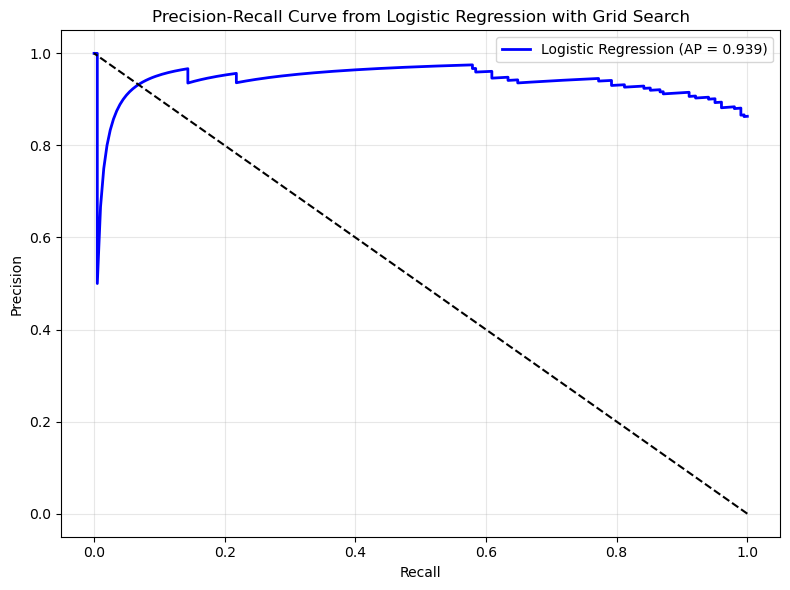

In [22]:
precision, recall, thresholds = precision_recall_curve(y_val, y_pred_proba)
avg_precision = average_precision_score(y_val, y_pred_proba)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(
    recall,
    precision,
    label=f"Logistic Regression (AP = {avg_precision:.3f})",
    color="blue",
    linewidth=2,
)
plt.plot([1, 0], [0, 1], linestyle="--", color="black")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve from Logistic Regression with Grid Search")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

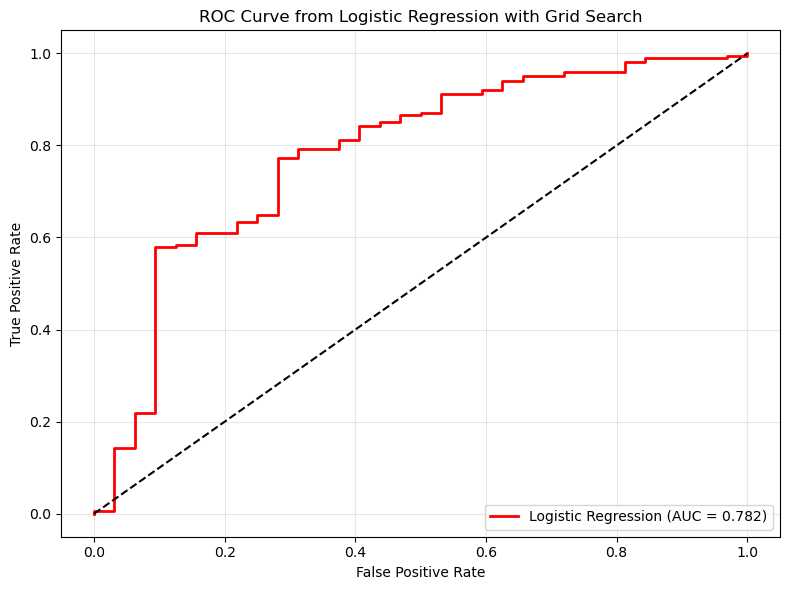

In [23]:
# Compute FPR, TPR
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
auc_score = roc_auc_score(y_val, y_pred_proba)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})",
    color="red",
    linewidth=2,
)
plt.plot([0, 1], [0, 1], linestyle="--", color="black")  # Random chance line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve from Logistic Regression with Grid Search")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()